In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational"
)
model = ChatHuggingFace(llm = llm)

c:\langGraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class JokeClass(TypedDict):
    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeClass):
    prompt = f"Generate a joke on the topic {state['topic']}"
    response = model.invoke(prompt).content


    return {'joke': response}

In [6]:
def genarate_explanation(state: JokeClass):
    prompt = f"Write an explanation for the joke - {state['joke']}"
    response = model.invoke(prompt)

    return {'explanation': response}

In [7]:
graph = StateGraph(JokeClass)

graph.add_node('generate_joke', generate_joke)
graph.add_node('genarate_explanation', genarate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'genarate_explanation')
graph.add_edge('genarate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

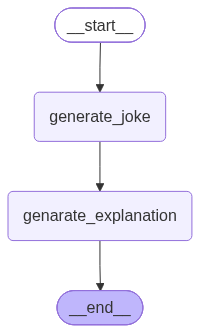

In [8]:
workflow

In [9]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic': 'pizza'}, config= config1)

{'topic': 'pizza',
 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.",
 'explanation': AIMessage(content='A play on words!\n\nThis joke is a play on the phrase "crusty under the pressure," which is an idiom that means feeling overwhelmed or stressed. In this joke, the phrase is used literally to describe a pizza, which has a crust. The wordplay is the clever twist on the usual meaning of the phrase, and it creates a humorous connection between the pizza\'s crust and its emotional state.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 39, 'total_tokens': 122}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03d97-679f-75b1-a7fe-67166ed564ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 83, 'total_tokens': 122})}

In [10]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.", 'explanation': AIMessage(content='A play on words!\n\nThis joke is a play on the phrase "crusty under the pressure," which is an idiom that means feeling overwhelmed or stressed. In this joke, the phrase is used literally to describe a pizza, which has a crust. The wordplay is the clever twist on the usual meaning of the phrase, and it creates a humorous connection between the pizza\'s crust and its emotional state.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 39, 'total_tokens': 122}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03d97-679f-75b1-a7fe-67166ed564ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 83, 'total_tokens': 122})}, next=()

In [11]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.", 'explanation': AIMessage(content='A play on words!\n\nThis joke is a play on the phrase "crusty under the pressure," which is an idiom that means feeling overwhelmed or stressed. In this joke, the phrase is used literally to describe a pizza, which has a crust. The wordplay is the clever twist on the usual meaning of the phrase, and it creates a humorous connection between the pizza\'s crust and its emotional state.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 39, 'total_tokens': 122}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03d97-679f-75b1-a7fe-67166ed564ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 83, 'total_tokens': 122})}, next=(

### Time Travel

In [19]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1a137f-7adc-6f7a-8000-76bfa64b2d93"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1a137f-7adc-6f7a-8000-76bfa64b2d93'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-26T10:21:57.583181+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a137f-7aae-686b-bfff-cb8f82cc2af7'}}, tasks=(PregelTask(id='a6311d4e-07e8-8922-4664-9c368ee73d40', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure."}),), interrupts=())

In [21]:
workflow.invoke(None, {"configurable":{"thread_id": "1", "checkpoint_id": "1f1a137f-7adc-6f7a-8000-76bfa64b2d93"}})

{'topic': 'pizza',
 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty and had a lot of topping issues.",
 'explanation': AIMessage(content='The joke relies on a series of wordplay puns that create a humorous connection between the setup and the punchline. Here\'s a breakdown of the explanation:\n\n1.  **Pizza as a subject**: The joke starts by introducing "pizza" as the subject of the joke. This is a common setup for a humorous joke, where a mundane or everyday object is given human-like qualities.\n\n2.  **Therapy as the destination**: The setup proceeds to ask why the pizza went to therapy. This implies that the pizza is experiencing some sort of distress or discomfort, which is a common reason for people to seek therapy.\n\n3.  **Puns on "crusty" and "tough issues"**: The punchline uses the word "crusty" in a dual sense. It refers to the crust of the pizza, which is a literal characteristic of pizza. However, "crusty" can also be used to descr

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty and had a lot of topping issues.", 'explanation': AIMessage(content='The joke relies on a series of wordplay puns that create a humorous connection between the setup and the punchline. Here\'s a breakdown of the explanation:\n\n1.  **Pizza as a subject**: The joke starts by introducing "pizza" as the subject of the joke. This is a common setup for a humorous joke, where a mundane or everyday object is given human-like qualities.\n\n2.  **Therapy as the destination**: The setup proceeds to ask why the pizza went to therapy. This implies that the pizza is experiencing some sort of distress or discomfort, which is a common reason for people to seek therapy.\n\n3.  **Puns on "crusty" and "tough issues"**: The punchline uses the word "crusty" in a dual sense. It refers to the crust of the pizza, which is a literal characteristic of pizza. However, "crusty" can a

### Updating State

In [25]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1a137f-7adc-6f7a-8000-76bfa64b2d93", "checkpoint_ns": ""}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a13f0-4c27-67ce-8001-b5cfb65945b3'}}

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a13f0-4c27-67ce-8001-b5cfb65945b3'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-26T11:12:26.005021+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a137f-7adc-6f7a-8000-76bfa64b2d93'}}, tasks=(PregelTask(id='6ca1a72c-581b-86de-0285-ee85cfac7fa5', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty and had a lot of topping issues.", 'explanation': AIMessage(content='The joke relies on a series of wordplay puns that create a humorous connection between the setup and the punchline. Here\'s a breakdown of the explanation:\n\n1.  **Pizza as a subj

In [27]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1a13f0-4c27-67ce-8001-b5cfb65945b3"}})

{'topic': 'samosa',
 'joke': "Here's one:\n\nWhy did the samosa go to the party?\n\nBecause it was a flaky friend! (get it? flaky like the pastry, but also a friend who's a bit unreliable?)",
 'explanation': AIMessage(content='A delightful play on words!\n\nThe joke relies on a double meaning of the word "flaky". In this case, the speaker is making a pun on the characteristics of a samosa, a type of Indian pastry that is typically made with layers of dough (flaky layers) and filled with savory ingredients. The "flaky" part of the pastry refers to its texture, which is often described as flaky or layered.\n\nHowever, the speaker also uses "flaky" to imply that the samosa is an unreliable friend, much like someone who is flaky in their commitments or relationships. This wordplay creates a clever connection between the setup (a samosa going to a party) and the punchline (it\'s a flaky friend), making the joke a delightful and amusing play on words.', additional_kwargs={}, response_metadat

In [28]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': "Here's one:\n\nWhy did the samosa go to the party?\n\nBecause it was a flaky friend! (get it? flaky like the pastry, but also a friend who's a bit unreliable?)", 'explanation': AIMessage(content='A delightful play on words!\n\nThe joke relies on a double meaning of the word "flaky". In this case, the speaker is making a pun on the characteristics of a samosa, a type of Indian pastry that is typically made with layers of dough (flaky layers) and filled with savory ingredients. The "flaky" part of the pastry refers to its texture, which is often described as flaky or layered.\n\nHowever, the speaker also uses "flaky" to imply that the samosa is an unreliable friend, much like someone who is flaky in their commitments or relationships. This wordplay creates a clever connection between the setup (a samosa going to a party) and the punchline (it\'s a flaky friend), making the joke a delightful and amusing play on words.', additional_kwargs=

In [12]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({"topic": "pasta"}, config= config2)

{'topic': 'pasta',
 'joke': 'Here\'s one:\n\nWhy did the spaghetti go to therapy?\n\nBecause it was feeling a little "drained" and needed to "knot" out its problems!',
 'explanation': AIMessage(content='A play on words! The joke relies on two types of wordplay:\n\n1. **Double meaning of "drained"**: In this context, "drained" can refer to both the emotional state of being drained of energy and enthusiasm, as well as the literal state of being depleted of liquid, like a sauce being drained from spaghetti. This double meaning creates a clever connection between the setup and the punchline.\n2. **Play on "knot"**: A knot in a rope or string can also be a colloquialism for a problem or issue. The punchline "knot out its problems" is a clever play on words, using the same concept of a knot in a rope, but also referencing the idea of "working out" or "talking out" one\'s problems in therapy.\n\nThe joke requires a quick mental shift to understand the wordplay, but once the connection is made

In [13]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Here\'s one:\n\nWhy did the spaghetti go to therapy?\n\nBecause it was feeling a little "drained" and needed to "knot" out its problems!', 'explanation': AIMessage(content='A play on words! The joke relies on two types of wordplay:\n\n1. **Double meaning of "drained"**: In this context, "drained" can refer to both the emotional state of being drained of energy and enthusiasm, as well as the literal state of being depleted of liquid, like a sauce being drained from spaghetti. This double meaning creates a clever connection between the setup and the punchline.\n2. **Play on "knot"**: A knot in a rope or string can also be a colloquialism for a problem or issue. The punchline "knot out its problems" is a clever play on words, using the same concept of a knot in a rope, but also referencing the idea of "working out" or "talking out" one\'s problems in therapy.\n\nThe joke requires a quick mental shift to understand the wordplay, but once the

In [17]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Here\'s one:\n\nWhy did the spaghetti go to therapy?\n\nBecause it was feeling a little "drained" and needed to "knot" out its problems!', 'explanation': AIMessage(content='A play on words! The joke relies on two types of wordplay:\n\n1. **Double meaning of "drained"**: In this context, "drained" can refer to both the emotional state of being drained of energy and enthusiasm, as well as the literal state of being depleted of liquid, like a sauce being drained from spaghetti. This double meaning creates a clever connection between the setup and the punchline.\n2. **Play on "knot"**: A knot in a rope or string can also be a colloquialism for a problem or issue. The punchline "knot out its problems" is a clever play on words, using the same concept of a knot in a rope, but also referencing the idea of "working out" or "talking out" one\'s problems in therapy.\n\nThe joke requires a quick mental shift to understand the wordplay, but once th

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.", 'explanation': AIMessage(content='A play on words!\n\nThis joke is a play on the phrase "crusty under the pressure," which is an idiom that means feeling overwhelmed or stressed. In this joke, the phrase is used literally to describe a pizza, which has a crust. The wordplay is the clever twist on the usual meaning of the phrase, and it creates a humorous connection between the pizza\'s crust and its emotional state.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 39, 'total_tokens': 122}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03d97-679f-75b1-a7fe-67166ed564ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 83, 'total_tokens': 122})}, next=(